In [3]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [9]:
# Extracción de precios historicos en un rango determinad
apple = yf.download(tickers = 'aapl', start = "2021-04-06", end = "2023-04-06", rounding = True)
apple

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-04-06,122.93,123.82,122.38,123.21,80171300
2021-04-07,124.57,124.59,121.89,122.56,83466700
2021-04-08,126.97,127.00,125.18,125.60,88844600
2021-04-09,129.54,129.58,126.10,126.42,106686700
2021-04-12,127.83,129.40,127.23,129.07,91420000
...,...,...,...,...,...
2023-03-30,160.04,160.15,158.97,159.22,49501700
2023-03-31,162.55,162.64,159.60,160.12,68749800


In [11]:
# Extraemos solo la columna de cierre
apple = apple['Close']['AAPL']
apple

Date
2021-04-06    122.93
2021-04-07    124.57
2021-04-08    126.97
2021-04-09    129.54
2021-04-12    127.83
               ...  
2023-03-30    160.04
2023-03-31    162.55
2023-04-03    163.80
2023-04-04    163.26
2023-04-05    161.42
Name: AAPL, Length: 505, dtype: float64

In [13]:
# Definimos la base de entrenamiento y prueba
apple.index = pd.to_datetime(apple.index)
len_train = int(len(apple) * 0.8)
len_train

404

In [15]:
len_test = int(len(apple) * 0.2)
len_test

101

In [17]:
train = apple[0:len_train]
train

Date
2021-04-06    122.93
2021-04-07    124.57
2021-04-08    126.97
2021-04-09    129.54
2021-04-12    127.83
               ...  
2022-11-02    142.50
2022-11-03    136.46
2022-11-04    136.20
2022-11-07    136.73
2022-11-08    137.30
Name: AAPL, Length: 404, dtype: float64

In [19]:
test = apple[len_train:]
test

Date
2022-11-09    132.74
2022-11-10    144.55
2022-11-11    147.34
2022-11-14    145.94
2022-11-15    147.67
               ...  
2023-03-30    160.04
2023-03-31    162.55
2023-04-03    163.80
2023-04-04    163.26
2023-04-05    161.42
Name: AAPL, Length: 101, dtype: float64

[1.         0.97625742 0.95361751 0.93385713 0.91673918 0.89920427
 0.87971773 0.85896358 0.83914503 0.82180734 0.80535622 0.79065855
 0.76990459 0.74987849 0.73088296 0.71190918 0.69503998 0.67681054
 0.65926847 0.64036888 0.61933844 0.59842512 0.57730473 0.55920539
 0.54064307 0.51824555 0.49572944]


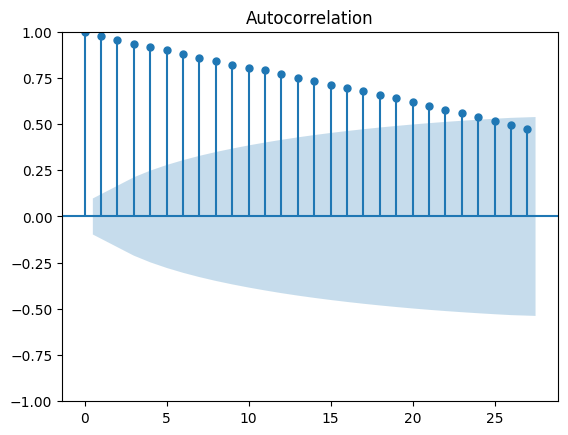

In [25]:
# Grafica de autoccorelación
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

acf_array = acf(train)
print(acf_array)

# Grafico con un nivel de confianza del 95%
plot_acf(train, alpha = 0.05)
plt.show()

In [27]:
from statsmodels.tsa.arima.model import ARIMA
#Fit an AR(1) model to the first simulated data
mod = ARIMA(train, order = (1,0,0))
res = mod.fit()

C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [33]:
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  404
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -990.546
Date:                Wed, 25 Mar 2026   AIC                           1987.093
Time:                        21:08:31   BIC                           1999.097
Sample:                             0   HQIC                          1991.845
                                - 404                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        144.3544      6.522     22.134      0.000     131.572     157.137
ar.L1          0.9825      0.010    103.237      0.000       0.964       1.001
sigma2         7.8267      0.444     17.609      0.0

In [35]:
predicciones = res.forecast(len(test))
predicciones

C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


404    137.423560
405    137.544957
406    137.664226
407    137.781407
408    137.896536
          ...    
500    143.083665
501    143.105922
502    143.127790
503    143.149275
504    143.170384
Name: predicted_mean, Length: 101, dtype: float64

In [37]:
# Obtener intervalos de confianza
conf = res.get_forecast(len(test)).conf_int(alpha = 0.05)
conf

C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,lower AAPL,upper AAPL
404,131.940306,142.906815
405,129.858075,145.231838
406,128.331356,146.997096
407,127.097587,148.465227
408,126.053961,149.739110
...,...,...
500,114.139463,172.027866
501,114.144872,172.066973
502,114.150486,172.105095
503,114.156289,172.142261


In [39]:
# Obtener información mas detallada de los intervalos de confianza
fcast_res = res.get_forecast(len(test))
print(fcast_res.summary_frame(alpha = 0.05))

AAPL        mean    mean_se  mean_ci_lower  mean_ci_upper
404   137.423560   2.797630     131.940306     142.906815
405   137.544957   3.921950     129.858075     145.231838
406   137.664226   4.761756     128.331356     146.997096
407   137.781407   5.451029     127.097587     148.465227
408   137.896536   6.042241     126.053961     149.739110
..           ...        ...            ...            ...
500   143.083665  14.767721     114.139463     172.027866
501   143.105922  14.776318     114.144872     172.066973
502   143.127790  14.784611     114.150486     172.105095
503   143.149275  14.792611     114.156289     172.142261
504   143.170384  14.800330     114.162269     172.178498

[101 rows x 4 columns]


C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [41]:
# Colocamos una fecha para poder identificar mejor cada prediccion
test = pd.DataFrame(test)
predicciones = pd.DataFrame(predicciones)
test = test.reset_index()
predicciones = predicciones.reset_index()

In [43]:
test

,Date,AAPL
0,2022-11-09,132.74
1,2022-11-10,144.55
2,2022-11-11,147.34
3,2022-11-14,145.94
4,2022-11-15,147.67
...,...,...
96,2023-03-30,160.04
97,2023-03-31,162.55
98,2023-04-03,163.80
99,2023-04-04,163.26


In [45]:
predicciones

,index,predicted_mean
0,404,137.423560
1,405,137.544957
2,406,137.664226
3,407,137.781407
4,408,137.896536
...,...,...
96,500,143.083665
97,501,143.105922
98,502,143.127790
99,503,143.149275


In [47]:
# Calcular el nivel de error de las predicicones contra las pruebas
import numpy as np

acumulador1 = 0
acumulador2 = 0 

for contador in range(0,101):
    acumulador1 = acumulador1 + (test.iloc[contador] [1] - predicciones.iloc[contador][1]) ** 2
    acumulador2 = acumulador2 + np.abs((test.iloc[contador][1] - predicciones.iloc[contador][1]) / 
                                      test.iloc[contador][1])

mse = acumulador1 / 101
rmse = np.round(np.sqrt(mse),2)
mape = np.round((acumulador2 / 101) * 100,2)
print("RMSE = ", rmse, "MAPE = ", mape, "%")

KeyError: 1

In [49]:
import numpy as np

acumulador1 = 0
acumulador2 = 0 

for contador in range(0, 101):
    # Usamos .iloc[fila, columna] -> [contador, 1]
    valor_real = test.iloc[contador, 1]
    valor_pred = predicciones.iloc[contador, 1]
    
    acumulador1 += (valor_real - valor_pred) ** 2
    acumulador2 += np.abs((valor_real - valor_pred) / valor_real)

mse = acumulador1 / 101
rmse = np.round(np.sqrt(mse), 2)
mape = np.round((acumulador2 / 101) * 100, 2)

print(f"RMSE = {rmse}, MAPE = {mape}%")

RMSE = 9.56, MAPE = 5.69%


In [51]:
# Pronostico de los siguintes 5 períodos posteriores al ultimo dato historico
predicciones = res.forecast(len(test) + 5)
predicciones.tail(5)

C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


505    143.191123
506    143.211498
507    143.231517
508    143.251185
509    143.270509
Name: predicted_mean, dtype: float64

In [57]:
# Pronostico de confianza para los siguientes 5 períodos
conf = res.get_forecast(len(test) + 5).conf_int(alpha = 0.05)
conf.tail(5)

C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,lower AAPL,upper AAPL
505,114.168412,172.213833
506,114.174706,172.248290
507,114.181138,172.281896
508,114.187697,172.314673
509,114.194373,172.346644


In [61]:
# Quitamos los indices y ponemos las fecha de cada predicción
train = pd.DataFrame(train)
lista = test["Date"]
lista = pd.DataFrame(lista)
test.index = test["Date"]
test.drop(columns = ["Date"], inplace = True)
test

,AAPL
Date,
2022-11-09,132.74
2022-11-10,144.55
2022-11-11,147.34
2022-11-14,145.94
2022-11-15,147.67
...,...
2023-03-30,160.04
2023-03-31,162.55
2023-04-03,163.80


In [63]:
lista

,Date
Date,
2022-11-09,2022-11-09
2022-11-10,2022-11-10
2022-11-11,2022-11-11
2022-11-14,2022-11-14
2022-11-15,2022-11-15
...,...
2023-03-30,2023-03-30
2023-03-31,2023-03-31
2023-04-03,2023-04-03


In [67]:
# Agregamos 5 días habiles más
k = 5
lista2 = []
for day in range(1, 6):
    fecha = ((pd.to_datetime("2023-04-05") + pd.offsets.BDay(day)).date())
    lista2.append(fecha)
lista2 = pd.DataFrame(lista2, columns = ["Date"])
lista2["Date"] = pd.to_datetime(lista2["Date"])
lista2

,Date
0,2023-04-06
1,2023-04-07
2,2023-04-10
3,2023-04-11
4,2023-04-12


In [71]:
fechas = pd.concat([lista, lista2], ignore_index=True)
fechas = fechas.reset_index()
fechas

,index,Date
0,0,2022-11-09
1,1,2022-11-10
2,2,2022-11-11
3,3,2022-11-14
4,4,2022-11-15
...,...,...
101,101,2023-04-06
102,102,2023-04-07
103,103,2023-04-10
104,104,2023-04-11


In [73]:
fechas.drop(columns = ["index"], inplace = True)
fechas

,Date
0,2022-11-09
1,2022-11-10
2,2022-11-11
3,2022-11-14
4,2022-11-15
...,...
101,2023-04-06
102,2023-04-07
103,2023-04-10
104,2023-04-11


In [75]:
predicciones = pd.DataFrame(predicciones)
predicciones = predicciones.reset_index()
predicciones

,index,predicted_mean
0,404,137.423560
1,405,137.544957
2,406,137.664226
3,407,137.781407
4,408,137.896536
...,...,...
101,505,143.191123
102,506,143.211498
103,507,143.231517
104,508,143.251185


In [79]:
predicciones.drop(columns = ["index"], inplace = True)
predicciones

,predicted_mean
0,137.423560
1,137.544957
2,137.664226
3,137.781407
4,137.896536
...,...
101,143.191123
102,143.211498
103,143.231517
104,143.251185


In [83]:
frames = [fechas, predicciones]
result = pd.concat(frames, axis = 1, join = 'inner')
result.columns = ['Date', 'Predicciones']
result

,Date,Predicciones
0,2022-11-09,137.423560
1,2022-11-10,137.544957
2,2022-11-11,137.664226
3,2022-11-14,137.781407
4,2022-11-15,137.896536
...,...,...
101,2023-04-06,143.191123
102,2023-04-07,143.211498
103,2023-04-10,143.231517
104,2023-04-11,143.251185


In [85]:
# Averiguar que tipo de información maneja cada columna
print(result.dtypes)

Date            datetime64[s]
Predicciones          float64
dtype: object


In [87]:
# Hacemos que la fecha sea eel nuevo indice
result.index = result['Date']
result.drop(columns = ["Date"], inplace = True)
result

,Predicciones
Date,
2022-11-09,137.423560
2022-11-10,137.544957
2022-11-11,137.664226
2022-11-14,137.781407
2022-11-15,137.896536
...,...
2023-04-06,143.191123
2023-04-07,143.211498
2023-04-10,143.231517


In [91]:
# Hacemos lo mismo para los indicadorres de confianza
conf = conf.reset_index()
conf.drop(columns = ["index"], inplace = True)
conf

,lower AAPL,upper AAPL
0,131.940306,142.906815
1,129.858075,145.231838
2,128.331356,146.997096
3,127.097587,148.465227
4,126.053961,149.739110
...,...,...
101,114.168412,172.213833
102,114.174706,172.248290
103,114.181138,172.281896
104,114.187697,172.314673


In [93]:
# Junatmos ocn las fechas
frames = [fechas, conf]
intervalos = pd.concat(frames, axis = 1 , join = 'inner')
intervalos

,Date,lower AAPL,upper AAPL
0,2022-11-09,131.940306,142.906815
1,2022-11-10,129.858075,145.231838
2,2022-11-11,128.331356,146.997096
3,2022-11-14,127.097587,148.465227
4,2022-11-15,126.053961,149.739110
...,...,...,...
101,2023-04-06,114.168412,172.213833
102,2023-04-07,114.174706,172.248290
103,2023-04-10,114.181138,172.281896
104,2023-04-11,114.187697,172.314673


In [95]:
# Hacemos que la fecha sea el indice 
intervalos.index = intervalos['Date']
intervalos.drop(columns = ["Date"], inplace = True)
intervalos

,lower AAPL,upper AAPL
Date,,
2022-11-09,131.940306,142.906815
2022-11-10,129.858075,145.231838
2022-11-11,128.331356,146.997096
2022-11-14,127.097587,148.465227
2022-11-15,126.053961,149.739110
...,...,...
2023-04-06,114.168412,172.213833
2023-04-07,114.174706,172.248290
2023-04-10,114.181138,172.281896


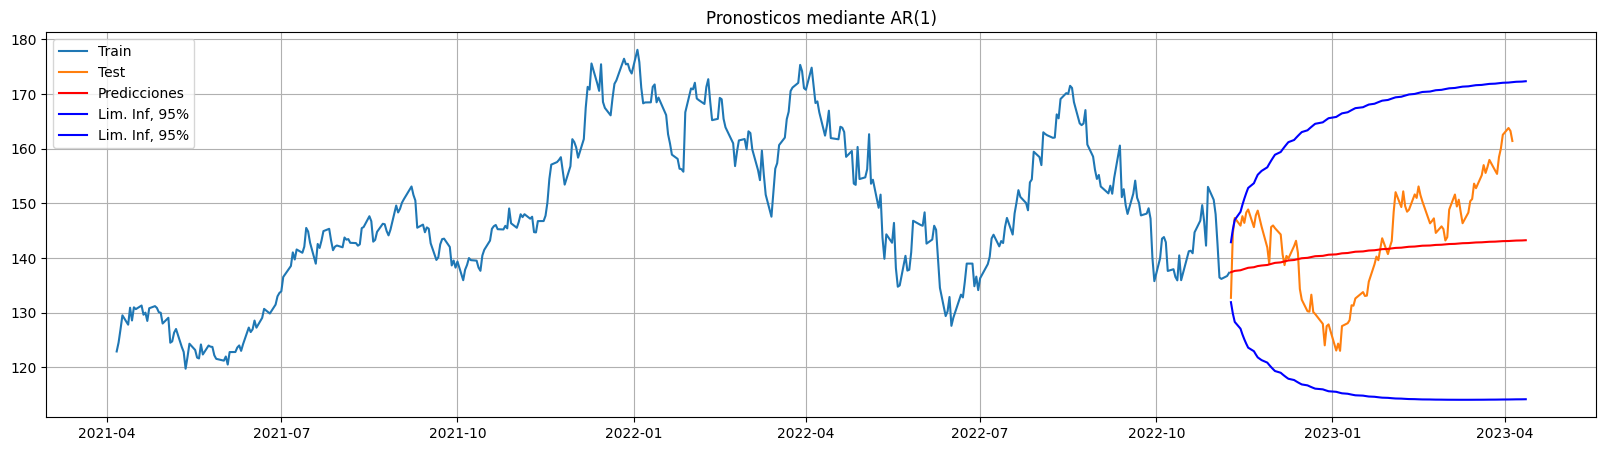

In [99]:
# Graficamso todos nuestros datos
plt.figure(figsize = (20,5))
plt.grid()
plt.plot(train, label = "Train")
plt.plot(test, label = "Test")
plt.plot(result, label = "Predicciones", color = "red")
plt.plot(intervalos['lower AAPL'], label = "Lim. Inf, 95%", color = "blue")
plt.plot(intervalos['upper AAPL'], label = "Lim. Inf, 95%", color = "blue")
plt.legend(loc = "best")
plt.title("Pronosticos mediante AR(1)")
plt.show()

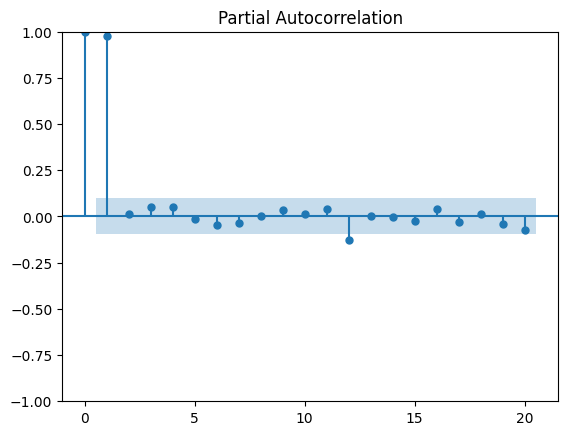

In [101]:
# Determinación del valor adecuado de p para AR(p) a partir de la función de Autocorrelación parcial
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(train, lags = 20)
plt.show()

### Conclusión: El modelos AR(1) parece ser el más adecuado

C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._

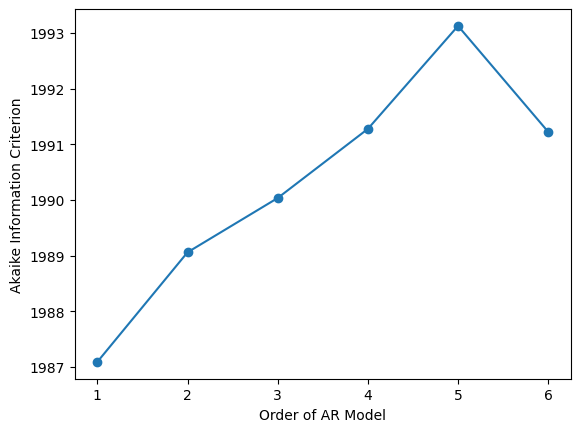

In [106]:
# Determinación del valor adecuado de p para AR(p) a partir del criterio de información Bayesiano
# Fit the data to an AR(p) for p = 0,...,6 and save the BIC
AIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(train, order = (p,0,0))
    res = mod.fit()
# Save BIC for AR(p)
    AIC[p] = res.aic

# Plot the BIC as a function of p
plt.plot(range(1,7), AIC[1:7], marker = 'o')
plt.xlabel('Order of AR Model')
plt.ylabel('Akaike Information Criterion')
plt.show()

C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._

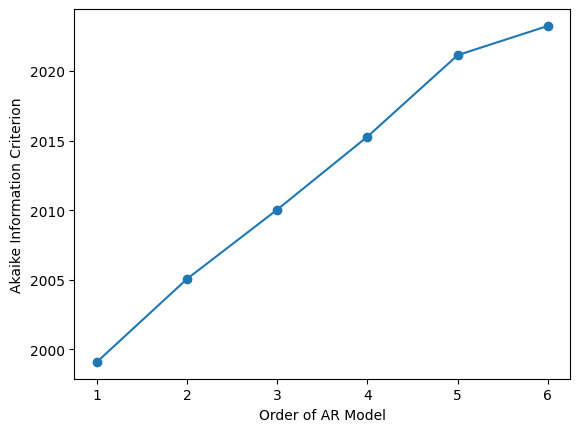

In [108]:
# Determinación del valor adecuado de p para AR(p) a partir del criterio de información Bayesiano
# Fit the data to an AR(p) for p = 0,...,6 and save the BIC
AIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(train, order = (p,0,0))
    res = mod.fit()
# Save BIC for AR(p)
    AIC[p] = res.bic

# Plot the BIC as a function of p
plt.plot(range(1,7), AIC[1:7], marker = 'o')
plt.xlabel('Order of AR Model')
plt.ylabel('Akaike Information Criterion')
plt.show()

### Conclusion: En ambos indices se tiene el menor valor para p = 1. Se recomienda utilizar AR(1)  